Using device: cpu

IMPROVED LSTM WITH PROPER VALIDATION

PROCESSING ASPECT RATIO 0.3
Loading 0.3.xlsx...
  Subsampling from 25000 to 15000 rows
Creating sequences...
  Created 14990 sequences
Normalizing...
✓ Train: (8994, 10, 4), Val: (2998, 10, 4), Test: (2998, 10, 4)

Training AR 0.3
Training...
Epoch   1/60 | Train: 0.559082 | Val: 0.073595 | Best: 0.073595 | LR: 0.001000
Epoch   5/60 | Train: 0.058221 | Val: 0.004613 | Best: 0.004168 | LR: 0.001000
Epoch  10/60 | Train: 0.050038 | Val: 0.016853 | Best: 0.003918 | LR: 0.001000
Epoch  15/60 | Train: 0.046131 | Val: 0.006698 | Best: 0.003325 | LR: 0.001000
Epoch  20/60 | Train: 0.051796 | Val: 0.004242 | Best: 0.002313 | LR: 0.001000
Epoch  25/60 | Train: 0.041965 | Val: 0.002864 | Best: 0.001427 | LR: 0.000500
Epoch  30/60 | Train: 0.047314 | Val: 0.003469 | Best: 0.001427 | LR: 0.000250
Epoch  35/60 | Train: 0.044840 | Val: 0.002802 | Best: 0.001328 | LR: 0.000250
Epoch  40/60 | Train: 0.044525 | Val: 0.007385 | Best: 0.001328 | LR

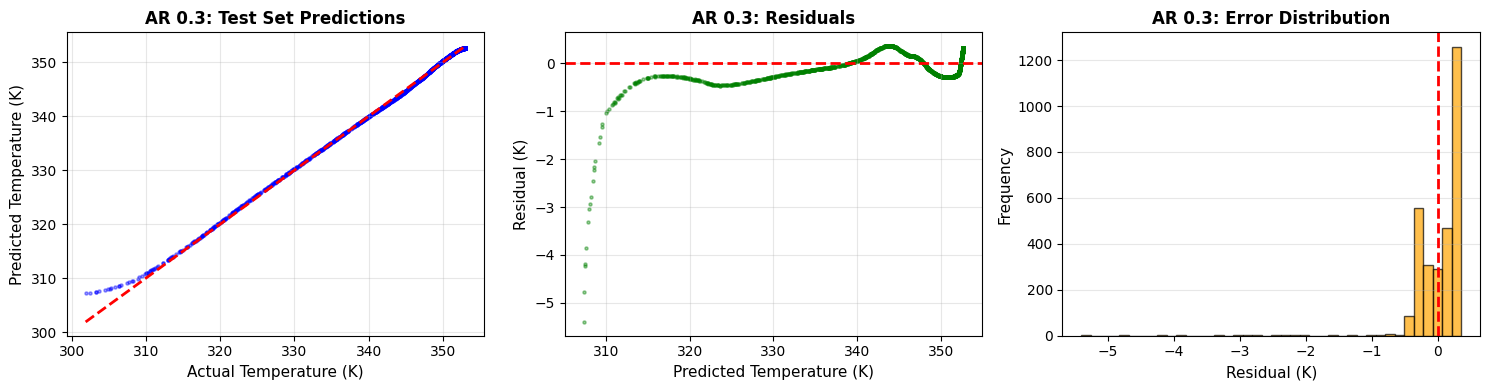


PROCESSING ASPECT RATIO 0.4
Loading 0.4.xlsx...
  Subsampling from 27497 to 15000 rows
Creating sequences...
  Created 14990 sequences
Normalizing...
✓ Train: (8994, 10, 4), Val: (2998, 10, 4), Test: (2998, 10, 4)

Training AR 0.4
Training...
Epoch   1/60 | Train: 0.445275 | Val: 0.040573 | Best: 0.040573 | LR: 0.001000
Epoch   5/60 | Train: 0.049548 | Val: 0.003473 | Best: 0.003473 | LR: 0.001000
Epoch  10/60 | Train: 0.045618 | Val: 0.001635 | Best: 0.001635 | LR: 0.001000
Epoch  15/60 | Train: 0.044868 | Val: 0.001809 | Best: 0.001635 | LR: 0.001000
Epoch  20/60 | Train: 0.045053 | Val: 0.003846 | Best: 0.001229 | LR: 0.000500
Epoch  25/60 | Train: 0.042783 | Val: 0.001680 | Best: 0.001229 | LR: 0.000250
Epoch  30/60 | Train: 0.046124 | Val: 0.001984 | Best: 0.001138 | LR: 0.000250
Epoch  35/60 | Train: 0.042463 | Val: 0.001401 | Best: 0.001138 | LR: 0.000125
Early stopping at epoch 38
✓ Restored best model (val loss: 0.001138)

Evaluating...

──────────────────────────────────────

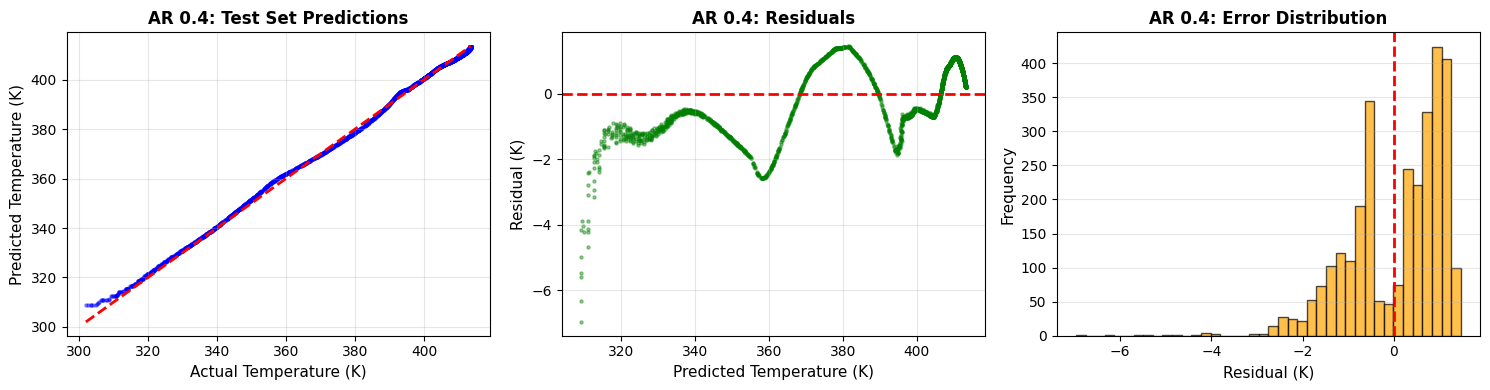


PROCESSING ASPECT RATIO 0.5
Loading 0.5.xlsx...
  Subsampling from 25000 to 15000 rows
Creating sequences...
  Created 14990 sequences
Normalizing...
✓ Train: (8994, 10, 4), Val: (2998, 10, 4), Test: (2998, 10, 4)

Training AR 0.5
Training...
Epoch   1/60 | Train: 0.528572 | Val: 0.043688 | Best: 0.043688 | LR: 0.001000
Epoch   5/60 | Train: 0.049991 | Val: 0.004616 | Best: 0.004616 | LR: 0.001000
Epoch  10/60 | Train: 0.043958 | Val: 0.004847 | Best: 0.003357 | LR: 0.001000
Epoch  15/60 | Train: 0.040854 | Val: 0.003048 | Best: 0.002629 | LR: 0.001000
Epoch  20/60 | Train: 0.041972 | Val: 0.003407 | Best: 0.002213 | LR: 0.001000
Epoch  25/60 | Train: 0.039417 | Val: 0.003305 | Best: 0.001854 | LR: 0.001000
Epoch  30/60 | Train: 0.040725 | Val: 0.003609 | Best: 0.001389 | LR: 0.001000
Epoch  35/60 | Train: 0.038443 | Val: 0.002253 | Best: 0.001389 | LR: 0.000500
Early stopping at epoch 37
✓ Restored best model (val loss: 0.001389)

Evaluating...

──────────────────────────────────────

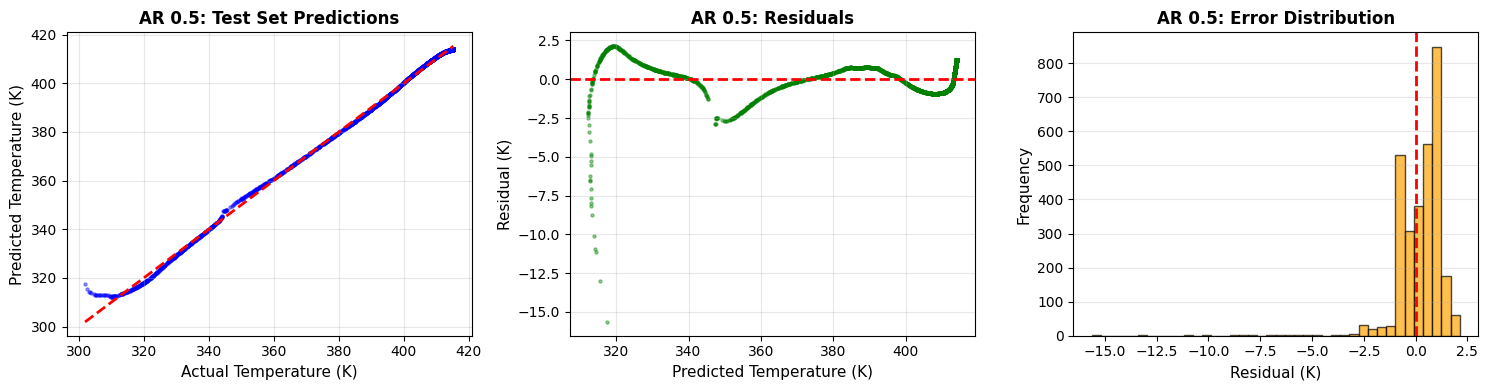


FINAL SUMMARY

 aspect_ratio  val_mae  val_rmse   val_r2  test_mae  test_rmse  test_r2   temp_min   temp_max  samples
          0.3 0.246809  0.317767 0.998786  0.248666   0.348564 0.998633 301.880829 353.011414     2998
          0.4 0.877617  1.009531 0.998872  0.882633   1.028639 0.998831 302.031311 413.517242     2998
          0.5 0.862949  1.096227 0.998626  0.856950   1.148337 0.998490 301.881439 415.300537     2998

✓ Results saved to 'improved_lstm_results.csv'

CHECK: If test R² significantly < val R², model is overfitting
GOOD: If test R² ≈ val R², model generalizes well


In [2]:
# ============================================================================
# IMPROVED LSTM WITH BETTER GENERALIZATION
# Fixes:
# 1. Proper train/val/test split (60/20/20)
# 2. More regularization to prevent overfitting
# 3. Earlier stopping
# 4. K-fold cross-validation option
# ============================================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
import gc
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============================================================================
# IMPROVED DATA LOADING (Train/Val/Test Split)
# ============================================================================

def load_and_preprocess_data(data_path, val_ratio=0.2, test_ratio=0.2, seq_length=10, max_samples=15000):
    """
    Load data with proper 3-way split to prevent overfitting.
    """
    print(f"Loading {data_path}...")

    data = pd.read_excel(data_path, usecols=['time', 'aspect_ratio', 'liquid_frac', 'Nu', 'T_pcm', 'T_battery'])
    data = data.sort_values('time').reset_index(drop=True)

    # Subsample if too large
    if len(data) > max_samples:
        print(f"  Subsampling from {len(data)} to {max_samples} rows")
        indices = np.linspace(0, len(data)-1, max_samples, dtype=int)
        data = data.iloc[indices].reset_index(drop=True)

    features = ['aspect_ratio', 'liquid_frac', 'Nu', 'T_pcm']
    target_col = 'T_battery'

    # Create sequences
    print("Creating sequences...")
    X_list = []
    y_list = []

    for i in range(len(data) - seq_length):
        X_list.append(data[features].iloc[i:i+seq_length].values.astype(np.float32))
        y_list.append(data[target_col].iloc[i+seq_length])

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)

    del X_list, y_list, data
    gc.collect()

    print(f"  Created {len(X)} sequences")

    # THREE-WAY SPLIT: Train/Val/Test
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_ratio, random_state=42, shuffle=True
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_ratio/(1-test_ratio), random_state=42, shuffle=True
    )

    del X, y, X_temp, y_temp
    gc.collect()

    # Normalize (using ONLY training data statistics)
    print("Normalizing...")
    X_mean = X_train.mean(axis=(0, 1)).astype(np.float32)
    X_std = X_train.std(axis=(0, 1)).astype(np.float32)
    y_mean = float(y_train.mean())
    y_std = float(y_train.std())

    X_train = ((X_train - X_mean) / (X_std + 1e-8)).astype(np.float32)
    X_val = ((X_val - X_mean) / (X_std + 1e-8)).astype(np.float32)
    X_test = ((X_test - X_mean) / (X_std + 1e-8)).astype(np.float32)

    y_train = ((y_train - y_mean) / (y_std + 1e-8)).astype(np.float32)
    y_val = ((y_val - y_mean) / (y_std + 1e-8)).astype(np.float32)
    y_test = ((y_test - y_mean) / (y_std + 1e-8)).astype(np.float32)

    norm_stats = (X_mean, X_std, y_mean, y_std)

    print(f"✓ Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

    return X_train, X_val, X_test, y_train, y_val, y_test, norm_stats


# ============================================================================
# IMPROVED LSTM WITH MORE REGULARIZATION
# ============================================================================

class ImprovedLSTM(nn.Module):
    def __init__(self, input_size=4, hidden_size=48, dropout=0.3):  # Smaller hidden size
        super().__init__()

        # 2-layer LSTM with higher dropout
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=dropout
        )

        # Attention
        self.attention = nn.Linear(hidden_size, 1)

        # More regularized FC
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 24),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(24, 1)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(attn_weights * lstm_out, dim=1)
        return self.fc(context)


# ============================================================================
# TRAINING WITH PROPER VALIDATION
# ============================================================================

def train_model(X_train, y_train, X_val, y_val, X_test, y_test, norm_stats, aspect_ratio):
    print(f"\n{'='*60}")
    print(f"Training AR {aspect_ratio}")
    print(f"{'='*60}")

    # Convert to tensors
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

    del X_train, y_train, X_val, y_val, X_test, y_test
    gc.collect()

    # DataLoader
    train_ds = torch.utils.data.TensorDataset(X_train_t, y_train_t)
    train_loader = torch.utils.data.DataLoader(
        train_ds,
        batch_size=128,
        shuffle=True,
        num_workers=0,
        pin_memory=True if device.type == 'cuda' else False
    )

    # Model with MORE regularization
    model = ImprovedLSTM(input_size=4, hidden_size=48, dropout=0.3).to(device)

    # Loss and optimizer with WEIGHT DECAY
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)  # Higher weight decay
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=5, factor=0.5  # Faster LR decay
    )

    # Training with EARLY STOPPING
    max_epochs = 60  # Reduced
    patience = 10   # Shorter patience
    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    print("Training...")
    for epoch in range(max_epochs):
        model.train()
        train_loss = 0

        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            pred = model(batch_X)
            loss = criterion(pred, batch_y)
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            train_loss += loss.item()

            if device.type == 'cuda':
                del batch_X, batch_y, pred, loss
                torch.cuda.empty_cache()

        train_loss /= len(train_loader)

        # Validation
        model.eval()
        with torch.no_grad():
            X_val_dev = X_val_t.to(device)
            y_val_dev = y_val_t.to(device)
            val_pred = model(X_val_dev)
            val_loss = criterion(val_pred, y_val_dev).item()

            if device.type == 'cuda':
                del X_val_dev, y_val_dev, val_pred
                torch.cuda.empty_cache()

        scheduler.step(val_loss)

        # Early stopping
        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        # Print every 5 epochs
        if (epoch + 1) % 5 == 0 or epoch == 0:
            lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch+1:3d}/{max_epochs} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | Best: {best_val_loss:.6f} | LR: {lr:.6f}")

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    # Restore best model
    if best_state:
        model.load_state_dict(best_state)
        print(f"✓ Restored best model (val loss: {best_val_loss:.6f})")

    del best_state
    gc.collect()

    return model, X_val_t, y_val_t, X_test_t, y_test_t


# ============================================================================
# EVALUATION ON BOTH VAL AND TEST
# ============================================================================

def evaluate_model(model, X_val_t, y_val_t, X_test_t, y_test_t, norm_stats, aspect_ratio):
    print("\nEvaluating...")

    model.eval()

    # Evaluate on VALIDATION set
    with torch.no_grad():
        X_val_dev = X_val_t.to(device)
        y_val_pred = model(X_val_dev).cpu().numpy().flatten()

    y_val_actual = y_val_t.cpu().numpy().flatten()

    # Evaluate on TEST set (UNSEEN DATA)
    with torch.no_grad():
        X_test_dev = X_test_t.to(device)
        y_test_pred = model(X_test_dev).cpu().numpy().flatten()

    y_test_actual = y_test_t.cpu().numpy().flatten()

    # Denormalize
    y_mean, y_std = norm_stats[2], norm_stats[3]

    y_val_actual = y_val_actual * y_std + y_mean
    y_val_pred = y_val_pred * y_std + y_mean

    y_test_actual = y_test_actual * y_std + y_mean
    y_test_pred = y_test_pred * y_std + y_mean

    # Metrics for BOTH sets
    metrics = {
        'aspect_ratio': aspect_ratio,
        'val_mae': mean_absolute_error(y_val_actual, y_val_pred),
        'val_rmse': np.sqrt(mean_squared_error(y_val_actual, y_val_pred)),
        'val_r2': r2_score(y_val_actual, y_val_pred),
        'test_mae': mean_absolute_error(y_test_actual, y_test_pred),
        'test_rmse': np.sqrt(mean_squared_error(y_test_actual, y_test_pred)),
        'test_r2': r2_score(y_test_actual, y_test_pred),
        'temp_min': float(y_test_actual.min()),
        'temp_max': float(y_test_actual.max()),
        'samples': len(y_test_actual)
    }

    return metrics, y_test_pred, y_test_actual


# ============================================================================
# VISUALIZATION
# ============================================================================

def plot_predictions(y_test_actual, y_pred_actual, aspect_ratio):
    if len(y_test_actual) > 3000:
        indices = np.random.choice(len(y_test_actual), 3000, replace=False)
        y_test_plot = y_test_actual[indices]
        y_pred_plot = y_pred_actual[indices]
    else:
        y_test_plot = y_test_actual
        y_pred_plot = y_pred_actual

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Scatter
    axes[0].scatter(y_test_plot, y_pred_plot, alpha=0.4, s=5, c='blue')
    axes[0].plot([y_test_plot.min(), y_test_plot.max()],
                 [y_test_plot.min(), y_test_plot.max()], 'r--', lw=2)
    axes[0].set_xlabel('Actual Temperature (K)', fontsize=11)
    axes[0].set_ylabel('Predicted Temperature (K)', fontsize=11)
    axes[0].set_title(f'AR {aspect_ratio}: Test Set Predictions', fontweight='bold')
    axes[0].grid(True, alpha=0.3)

    # Residuals
    residuals = y_test_actual - y_pred_actual
    axes[1].scatter(y_pred_actual, residuals, alpha=0.4, s=5, c='green')
    axes[1].axhline(0, color='r', linestyle='--', lw=2)
    axes[1].set_xlabel('Predicted Temperature (K)', fontsize=11)
    axes[1].set_ylabel('Residual (K)', fontsize=11)
    axes[1].set_title(f'AR {aspect_ratio}: Residuals', fontweight='bold')
    axes[1].grid(True, alpha=0.3)

    # Histogram
    axes[2].hist(residuals, bins=40, alpha=0.7, edgecolor='black', color='orange')
    axes[2].axvline(0, color='r', linestyle='--', lw=2)
    axes[2].set_xlabel('Residual (K)', fontsize=11)
    axes[2].set_ylabel('Frequency', fontsize=11)
    axes[2].set_title(f'AR {aspect_ratio}: Error Distribution', fontweight='bold')
    axes[2].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()


# ============================================================================
# MAIN EXECUTION
# ============================================================================

aspect_configs = [
    {'ar': 0.3, 'path': '0.3.xlsx'},
    {'ar': 0.4, 'path': '0.4.xlsx'},
    {'ar': 0.5, 'path': '0.5.xlsx'},
]

all_metrics = []

print("\n" + "="*60)
print("IMPROVED LSTM WITH PROPER VALIDATION")
print("="*60)

for cfg in aspect_configs:
    ar = cfg['ar']
    path = cfg['path']

    print(f"\n{'='*60}")
    print(f"PROCESSING ASPECT RATIO {ar}")
    print(f"{'='*60}")

    # Load data with 3-way split
    X_train, X_val, X_test, y_train, y_val, y_test, norm_stats = load_and_preprocess_data(
        path, val_ratio=0.2, test_ratio=0.2, max_samples=15000
    )

    # Train
    model, X_val_t, y_val_t, X_test_t, y_test_t = train_model(
        X_train, y_train, X_val, y_val, X_test, y_test, norm_stats, ar
    )

    # Evaluate on BOTH validation and test
    metrics, y_pred, y_actual = evaluate_model(
        model, X_val_t, y_val_t, X_test_t, y_test_t, norm_stats, ar
    )
    all_metrics.append(metrics)

    print(f"\n{'─'*60}")
    print(f"RESULTS FOR AR {ar}:")
    print(f"  VALIDATION SET:")
    print(f"    MAE:  {metrics['val_mae']:.4f} K")
    print(f"    RMSE: {metrics['val_rmse']:.4f} K")
    print(f"    R²:   {metrics['val_r2']:.4f}")
    print(f"  TEST SET (UNSEEN):")
    print(f"    MAE:  {metrics['test_mae']:.4f} K")
    print(f"    RMSE: {metrics['test_rmse']:.4f} K")
    print(f"    R²:   {metrics['test_r2']:.4f}")
    print(f"  Temp range: {metrics['temp_min']:.2f} - {metrics['temp_max']:.2f} K")
    print(f"{'─'*60}")

    # Plot TEST set
    plot_predictions(y_actual, y_pred, ar)

    # Clean up
    del model, X_train, X_val, X_test, y_train, y_val, y_test
    del X_val_t, y_val_t, X_test_t, y_test_t
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.empty_cache()


# ============================================================================
# SUMMARY
# ============================================================================

print(f"\n{'='*60}")
print("FINAL SUMMARY")
print(f"{'='*60}\n")

results_df = pd.DataFrame(all_metrics)
print(results_df.to_string(index=False))

results_df.to_csv('improved_lstm_results.csv', index=False)
print(f"\n✓ Results saved to 'improved_lstm_results.csv'")
print(f"\n{'='*60}")
print("CHECK: If test R² significantly < val R², model is overfitting")
print("GOOD: If test R² ≈ val R², model generalizes well")
print(f"{'='*60}")
